In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from tqdm.auto import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading example file: ./LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data/LiPO_1/EIS_Charge_discharge/EIS_0/0_EIS.csv
Plotting Bode comparison...
Plotting Nyquist comparison...


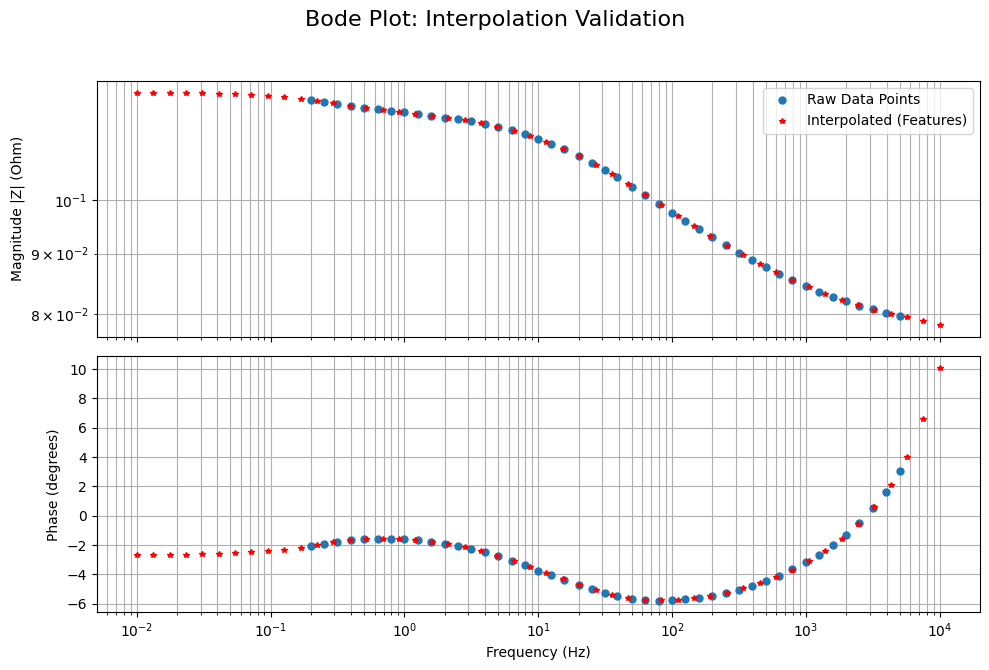

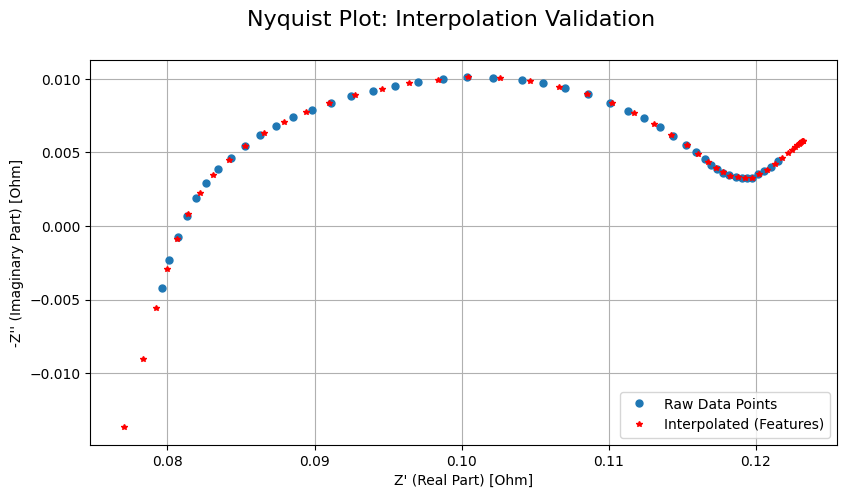

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. Setup ---
# (These are from your Phase 0 script)
param_columns = ['L1', 'R0', 'R1', 'CPE1_0', 'CPE1_1', 'W1']
col_names = ['Frequency(Hz)', 'R(ohm)', 'X(ohm)']
all_battery_data_EIS = pd.read_csv('all_battery_data_with_EIS_params.csv')

# 2. Define fixed frequencies for features
fixed_freqs = np.logspace(-2, 4, 50) # 50 points

# --- 2. Load ONE file as an example ---
# Get the first clean file path
df_cleaned = all_battery_data_EIS.dropna(
    subset=param_columns + ['SoH', 'SoC']
).reset_index(drop=True)

example_file_path = df_cleaned.iloc[10]['EIS_File']
print(f"Loading example file: {example_file_path}")

# --- 3. Get Raw Data ---
raw_df = pd.read_csv(example_file_path, sep='\t', names=col_names)
raw_df = raw_df.sort_values(by='Frequency(Hz)') 

f_x_raw = raw_df['Frequency(Hz)'].values
R_raw = raw_df['R(ohm)'].values
X_raw = raw_df['X(ohm)'].values
Z_raw = R_raw + 1j * X_raw

mag_raw = np.abs(Z_raw)
phase_raw = np.angle(Z_raw, deg=True)

# --- 4. Get Interpolated Data ---
# (Using the exact same logic as your script)
interp_R = interp1d(f_x_raw, R_raw, bounds_error=False, fill_value='extrapolate')
interp_X = interp1d(f_x_raw, X_raw, bounds_error=False, fill_value='extrapolate')

R_interp = interp_R(fixed_freqs)
X_interp = interp_X(fixed_freqs)
Z_interp = R_interp + 1j * X_interp

mag_interp = np.abs(Z_interp)
phase_interp = np.angle(Z_interp, deg=True)

# ==========================================================
# --- 5. Plot 1: BODE PLOT COMPARISON ---
# ==========================================================
print("Plotting Bode comparison...")
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig1.suptitle('Bode Plot: Interpolation Validation', fontsize=16)

# --- Magnitude Plot ---
ax1.loglog(f_x_raw, mag_raw, 'o', markersize=5, label='Raw Data Points')
ax1.loglog(fixed_freqs, mag_interp, '*', color='red', lw=2, markersize=4, label='Interpolated (Features)')
ax1.set_ylabel('Magnitude |Z| (Ohm)')
ax1.legend()
ax1.grid(True, which='both')

# --- Phase Plot ---
ax2.semilogx(f_x_raw, phase_raw, 'o', markersize=5, label='Raw Data Points')
ax2.semilogx(fixed_freqs, phase_interp, '*', color='red', lw=2, markersize=4, label='Interpolated (Features)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Phase (degrees)')
ax2.grid(True, which='both')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# ==========================================================
# --- 6. Plot 2: NYQUIST PLOT COMPARISON ---
# ==========================================================
print("Plotting Nyquist comparison...")
fig2, ax3 = plt.subplots(figsize=(10, 5))
fig2.suptitle('Nyquist Plot: Interpolation Validation', fontsize=16)

ax3.plot(R_raw, -X_raw, 'o', markersize=5, label='Raw Data Points')
ax3.plot(R_interp, -X_interp, '*', color='red', lw=2, markersize=4, label='Interpolated (Features)')
ax3.set_xlabel("Z' (Real Part) [Ohm]")
ax3.set_ylabel("-Z'' (Imaginary Part) [Ohm]")
ax3.set_aspect('equal')
ax3.grid(True)
ax3.legend()

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Feature Extraction

In [2]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from scipy.interpolate import interp1d
from scipy.signal import find_peaks # <-- Make sure this is imported

all_battery_data_EIS = pd.read_csv('all_battery_data_with_EIS_params.csv')
param_columns = ['L1', 'R0', 'R1', 'CPE1_0', 'CPE1_1', 'W1']
col_names = ['Frequency(Hz)', 'R(ohm)', 'X(ohm)']

# 1. Clean and align all data
df_cleaned = all_battery_data_EIS.dropna(
    subset=param_columns + ['SoH', 'SoC'] # <-- Add 'Modified SoC'
).reset_index(drop=True)

# 2. Define fixed frequencies for features
fixed_freqs = np.logspace(-2, 4, 50) # 50 points from 0.01 Hz to 10 kHz

# 3. Loop through files and engineer X features
eis_features_list = []
for index, row in tqdm(df_cleaned.iterrows(), total=len(df_cleaned), desc="Processing Spectra"):
    f = row['EIS_File']
    
    # --- NEW: Get the SoC feature ---
    feat_SoC = row['SoC'] # This is your new contextual feature
    
    try:
        raw_df = pd.read_csv(f, sep='\t', names=col_names)
        raw_df = raw_df.sort_values(by='Frequency(Hz)') 
        
        f_x = raw_df['Frequency(Hz)'].values
        R = raw_df['R(ohm)'].values
        X = raw_df['X(ohm)'].values
        Z_imag_neg = -X
        
        # --- A. Calculate 6 Peak-Finding Features ---
        feat_R_ohmic = R[-1] 
        feat_R_low = R[0]
        indices, _ = find_peaks(Z_imag_neg, prominence=1e-4) 
        
        if len(indices) == 2:
            feat_Peak_LF_Height = Z_imag_neg[indices[0]]
            feat_Peak_LF_Freq = f_x[indices[0]]
            feat_Peak_HF_Height = Z_imag_neg[indices[1]]
            feat_Peak_HF_Freq = f_x[indices[1]]
        elif len(indices) == 1:
            feat_Peak_LF_Height = Z_imag_neg[indices[0]]
            feat_Peak_LF_Freq = f_x[indices[0]]
            feat_Peak_HF_Height = 0.0 
            feat_Peak_HF_Freq = 0.0
        else:
            feat_Peak_LF_Height = 0.0
            feat_Peak_LF_Freq = 0.0
            feat_Peak_HF_Height = 0.0
            feat_Peak_HF_Freq = 0.0

        plot_features_array = np.array([
            feat_R_ohmic, feat_R_low, 
            feat_Peak_LF_Height, feat_Peak_LF_Freq,
            feat_Peak_HF_Height, feat_Peak_HF_Freq
        ])
        
        # --- NEW: B. Calculate 2 Phase-Based Features ---
        Z_phase_deg = np.angle(R + 1j * X, deg=True)
        feat_phase_min = np.min(Z_phase_deg)
        feat_phase_min_freq = f_x[np.argmin(Z_phase_deg)]
        
        phase_features_array = np.array([feat_phase_min, feat_phase_min_freq])

        # --- C. Calculate 100 Interpolated Features ---
        interp_R = interp1d(f_x, R, bounds_error=False, fill_value='extrapolate')
        interp_X = interp1d(f_x, X, bounds_error=False, fill_value='extrapolate')
        R_features = interp_R(fixed_freqs)
        X_features = interp_X(fixed_freqs)
        
        # --- D. Combine ALL features (100 + 6 + 2 + 1 = 109 features) ---
        features = np.concatenate([
            R_features, 
            X_features, 
            plot_features_array, 
            phase_features_array,
            np.array([feat_SoC]) # Add SoC
        ])
        eis_features_list.append(features)
        
    except Exception as e:
        tqdm.write(f"Warning: Could not process file {f}. Error: {e}")
        eis_features_list.append(None)

# 4. Create the final aligned X and y DataFrames
r_cols = [f'R_{freq:.2f}Hz' for freq in fixed_freqs]
x_cols = [f'X_{freq:.2f}Hz' for freq in fixed_freqs]
plot_feature_names = [
    'R_ohmic', 'R_low', 'Peak_LF_Height', 'Peak_LF_Freq', 
    'Peak_HF_Height', 'Peak_HF_Freq'
]
phase_feature_names = ['Phase_Min', 'Phase_Min_Freq']
context_feature_names = ['SoC'] # Your new feature

# Combine all column names
all_feature_names = (
    r_cols + x_cols + 
    plot_feature_names + 
    phase_feature_names + 
    context_feature_names
)

X_features_df = pd.DataFrame(eis_features_list, columns=all_feature_names)
y_params_df = df_cleaned[param_columns]
y_soh_df = df_cleaned[['SoH']] # (This isn't used by the GPR, but good to have)

# 5. Drop any rows that failed feature engineering
failed_indices = X_features_df[X_features_df.isnull().any(axis=1)].index
X_features_final = X_features_df.drop(failed_indices)
y_params_final = y_params_df.drop(failed_indices)
y_soh_final = y_soh_df.drop(failed_indices)

print(f"Data ready: X_features ({X_features_final.shape}), y_params ({y_params_final.shape})")

Processing Spectra: 100%|██████████| 549/549 [00:00<00:00, 1479.71it/s]

Data ready: X_features ((549, 109)), y_params ((549, 6))


# Random Forest Model

In [3]:
X = X_features_final
y = y_params_final
param_columns = ['L1', 'R0', 'R1', 'CPE1_0', 'CPE1_1', 'W1']

# --- 2. Split Data (using .values) ---
# --- THIS IS THE FIX ---
# Convert to NumPy arrays to train without feature names
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=42
)

# --- 3. Define the Hyperparameter Grid (Distribution) ---
param_dist = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'max_features': [1.0, 0.5, 'sqrt'],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# --- 4. Initialize the Randomized Search ---
rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    verbose=51, # Use 51 for a tqdm-style progress bar
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error' 
)

# --- 5. Run the Search ---
print("Starting Hyperparameter Tuning...")
rf_random.fit(X_train, y_train) # Will now fit on a NumPy array

# --- 6. Show Best Parameters ---
print("\n--- Tuning Complete ---")
print(f"Best parameters found: {rf_random.best_params_}")
print(f"Best CV (Negative MSE) score: {rf_random.best_score_:.4f}")

# --- 7. Evaluate the BEST Model on the Test Set ---
print("\n--- Evaluating Best Model on Test Set ---")
best_model = rf_random.best_estimator_
y_pred = best_model.predict(X_test) # Predicts on a NumPy array

# --- Calculate RMSE (using integer indexing) ---
rmse_R0 = np.sqrt(mean_squared_error(y_test[:, param_columns.index('R0')], y_pred[:, param_columns.index('R0')]))
rmse_r0 = np.sqrt(mean_squared_error(y_test[:, param_columns.index('R1')], y_pred[:, param_columns.index('R1')]))
rmse_W1 = np.sqrt(mean_squared_error(y_test[:, param_columns.index('W1')], y_pred[:, param_columns.index('W1')]))

print(f"Test RMSE for R0 (Tuned): {rmse_R0:.4f} Ohms")
print(f"Test RMSE for R1 (Tuned): {rmse_r0:.4f} Ohms")
print(f"Test RMSE for W1 (Tuned): {rmse_W1:.4f} Ohms")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


[CV 2/3; 3/50] START bootstrap=False, max_depth=50, max_features=0.5, min_samples_leaf=4, min_samples_split=5, n_estimators=300
[CV 3/3; 2/50] START bootstrap=False, max_depth=30, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=700
[CV 2/3; 2/50] START bootstrap=False, max_depth=30, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=700
[CV 2/3; 1/50] START bootstrap=False, max_depth=40, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=300
[CV 1/3; 3/50] START bootstrap=False, max_depth=50, max_features=0.5, min_samples_leaf=4, min_samples_split=5, n_estimators=300
[CV 1/3; 2/50] START bootstrap=False, max_depth=30, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=700
[CV 1/3; 1/50] START bootstrap=False, max_depth=40, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=300
[CV 3/3; 1/50] START bootstrap=False, max_depth=40, max_features=sqrt, min_samples_leaf=4, min_samp

# XGBoost Model

In [4]:
X = X_features_final
y = y_params_final

# --- 2. Split Data (CRITICAL: Convert to NumPy arrays) ---
# This prevents the .dtype error you were seeing
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=42
)

# --- 3. Create the base model and wrapper ---
xgb = XGBRegressor(random_state=42)
xgb_multi = MultiOutputRegressor(xgb)

# --- 4. Define the Hyperparameter Grid ---
# Must use 'estimator__' prefix for the wrapper
param_dist = {
    'estimator__n_estimators': [100, 300, 500, 700],
    'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__max_depth': [5, 10, 20, 30],
    'estimator__subsample': [0.7, 0.8, 0.9, 1.0],
    'estimator__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# --- 5. Initialize and run the search ---
xgb_random = RandomizedSearchCV(
    estimator=xgb_multi,
    param_distributions=param_dist,
    n_iter=50, # Try 50 random combinations
    cv=3,       
    verbose=51,
    random_state=42,
    n_jobs=-1,  # Use all cores
    scoring='neg_mean_squared_error'
)

print("\nStarting Hyperparameter Tuning for XGBoost...")
xgb_random.fit(X_train, y_train)

# --- 6. Evaluate the best XGBoost model ---
print("\n--- Tuning Complete ---")
print(f"Best parameters found: {xgb_random.best_params_}")
print(f"Best CV (Negative MSE) score: {xgb_random.best_score_:.4f}")

print("\n--- Evaluating Best XGBoost Model on Test Set ---")
best_model = xgb_random.best_estimator_
y_pred = best_model.predict(X_test)

# --- 7. Calculate RMSE using integer indexing ---
rmse_R0 = np.sqrt(mean_squared_error(y_test[:, param_columns.index('R0')], y_pred[:, param_columns.index('R0')]))
rmse_r0 = np.sqrt(mean_squared_error(y_test[:, param_columns.index('R1')], y_pred[:, param_columns.index('R1')]))
rmse_W1 = np.sqrt(mean_squared_error(y_test[:, param_columns.index('W1')], y_pred[:, param_columns.index('W1')]))

print(f"Test RMSE for R0 (Tuned XGB): {rmse_R0:.4f} Ohms")
print(f"Test RMSE for R1 (Tuned XGB): {rmse_r0:.4f} Ohms")
print(f"Test RMSE for W1 (Tuned XGB): {rmse_W1:.4f} Ohms")


Starting Hyperparameter Tuning for XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV 3/3; 1/50] START estimator__colsample_bytree=0.9, estimator__learning_rate=0.01, estimator__max_depth=5, estimator__n_estimators=700, estimator__subsample=0.8
[CV 2/3; 3/50] START estimator__colsample_bytree=0.8, estimator__learning_rate=0.1, estimator__max_depth=30, estimator__n_estimators=700, estimator__subsample=0.7
[CV 3/3; 2/50] START estimator__colsample_bytree=0.8, estimator__learning_rate=0.05, estimator__max_depth=20, estimator__n_estimators=300, estimator__subsample=0.8
[CV 1/3; 3/50] START estimator__colsample_bytree=0.8, estimator__learning_rate=0.1, estimator__max_depth=30, estimator__n_estimators=700, estimator__subsample=0.7
[CV 2/3; 1/50] START estimator__colsample_bytree=0.9, estimator__learning_rate=0.01, estimator__max_depth=5, estimator__n_estimators=700, estimator__subsample=0.8
[CV 1/3; 1/50] START estimator__colsample_bytree=0.9, estimator__learning_r

# Gaussian Process Regression Model


🚀 Starting Hyperparameter Tuning for GPR (stabilized)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END model__estimator__alpha=0.01, model__estimator__kernel=1**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.1); total time=   1.7s
[CV] END model__estimator__alpha=0.01, model__estimator__kernel=1**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.1); total time=   1.7s
[CV] END model__estimator__alpha=0.01, model__estimator__kernel=1**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.1); total time=   1.8s
[CV] END model__estimator__alpha=0.01, model__estimator__kernel=1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1); total time=   1.9s
[CV] END model__estimator__alpha=0.01, model__estimator__kernel=1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1); total time=   1.9s
[CV] END model__estimator__alpha=0.01, model__estimator__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1); total time=   2.1s
[CV] END model__estimator__alpha=0.01, model__estimator__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1); total time=   2.3s
[CV] END mo

/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END model__estimator__alpha=0.01, model__estimator__kernel=1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1); total time=   1.7s
[CV] END model__estimator__alpha=0.001, model__estimator__kernel=1**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.1); total time=   1.5s


...

[CV] END model__estimator__alpha=0.001, model__estimator__kernel=1**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.1); total time=   1.8s
[CV] END model__estimator__alpha=0.001, model__estimator__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1); total time=   2.1s
[CV] END model__estimator__alpha=0.001, model__estimator__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1); total time=   2.0s
[CV] END model__estimator__alpha=0.001, model__estimator__kernel=1**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.1); total time=   1.6s
[CV] END model__estimator__alpha=0.001, model__estimator__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1); total time=   2.4s
[CV] END model__estimator__alpha=0.001, model__estimator__kernel=1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1); total time=   1.7s


/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END model__estimator__alpha=0.001, model__estimator__kernel=1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1); total time=   1.7s
[CV] END model__estimator__alpha=0.001, model__estimator__kernel=1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1); total time=   1.8s
[CV] END model__estimator__alpha=0.0001, model__estimator__kernel=1**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.1); total time=   1.7s
[CV] END model__estimator__alpha=0.0001, model__estimator__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1); total time=   2.0s
[CV] END model__estimator__alpha=0.0001, model__estimator__kernel=1**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.1); total time=   1.8s
[CV] END model__estimator__alpha=0.0001, model__estimator__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1); total time=   2.2s


/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END model__estimator__alpha=0.0001, model__estimator__kernel=1**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.1); total time=   1.8s
[CV] END model__estimator__alpha=0.0001, model__estimator__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1); total time=   2.4s
[CV] END model__estimator__alpha=0.0001, model__estimator__kernel=1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1); total time=   1.3s
[CV] END model__estimator__alpha=0.0001, model__estimator__kernel=1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1); total time=   1.3s
[CV] END model__estimator__alpha=0.0001, model__estimator__kernel=1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1); total time=   1.0s

--- ✅ Tuning Complete ---
Best parameters found: {'model__estimator__kernel': 1**2 * RBF(length_scale=5) + WhiteKernel(noise_level=1), 'model__estimator__alpha': 0.001}

--- RMSE per parameter ---
L1: 0.000000
R0: 0.010458
R1: 0.095563
CPE1_0: 0.806606
CPE1_1: 0.072553
W1: 0.000671


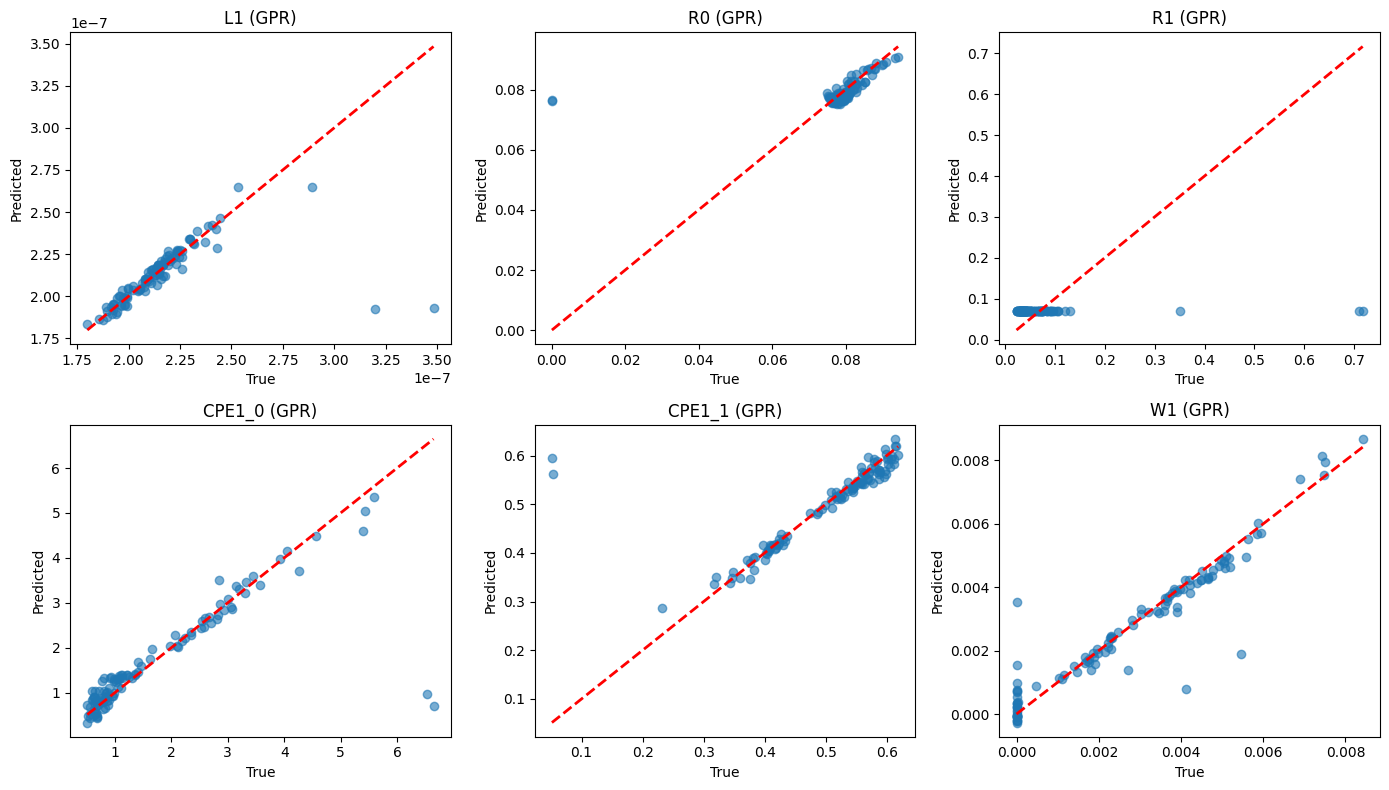

In [5]:
X = X_features_final
y = y_params_final
# ------------------------------------------
# 1. Split data
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=42
)
param_columns = ['L1', 'R0', 'R1', 'CPE1_0', 'CPE1_1', 'W1']

# ------------------------------------------
# 2. Define bounds & kernels (relaxed)
# ------------------------------------------
kernel_bounds = (1e-8, 1e8)
length_scale_bounds = (1e-3, 1e5)
noise_bounds = (1e-8, 1e4)

base_kernels = [
    ConstantKernel(1.0, kernel_bounds) * RBF(length_scale=1.0, length_scale_bounds=length_scale_bounds)
    + WhiteKernel(noise_level=1.0, noise_level_bounds=noise_bounds),
    ConstantKernel(1.0, kernel_bounds) * RBF(length_scale=10.0, length_scale_bounds=length_scale_bounds)
    + WhiteKernel(noise_level=0.1, noise_level_bounds=noise_bounds),
    ConstantKernel(1.0, kernel_bounds) * RBF(length_scale=5.0, length_scale_bounds=length_scale_bounds)
    + WhiteKernel(noise_level=1.0, noise_level_bounds=noise_bounds)
]

# ------------------------------------------
# 3. Scale both X and y inside pipeline
# ------------------------------------------
pipe = Pipeline([
    ('scaler_X', StandardScaler()),
    ('model', MultiOutputRegressor(
        GaussianProcessRegressor(normalize_y=True, random_state=42)
    ))
])

# ------------------------------------------
# 4. Hyperparameter tuning
# ------------------------------------------
param_dist = {
    'model__estimator__kernel': base_kernels,
    'model__estimator__alpha': [1e-2, 1e-3, 1e-4],
}

print("\n🚀 Starting Hyperparameter Tuning for GPR (stabilized)...")

gpr_random = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=9,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

gpr_random.fit(X_train, y_train)

print("\n--- ✅ Tuning Complete ---")
print("Best parameters found:", gpr_random.best_params_)

# ------------------------------------------
# 5. Evaluate and visualize
# ------------------------------------------
best_model = gpr_random.best_estimator_
y_pred = best_model.predict(X_test)

# Compute RMSE per parameter
print("\n--- RMSE per parameter ---")
for i, col in enumerate(param_columns):
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    print(f"{col}: {rmse:.6f}")

# ------------------------------------------
# 6. Diagnostic plots
# ------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(param_columns):
    axes[i].scatter(y_test[:, i], y_pred[:, i], alpha=0.6)
    axes[i].plot([y_test[:, i].min(), y_test[:, i].max()],
                 [y_test[:, i].min(), y_test[:, i].max()],
                 'r--', lw=2)
    axes[i].set_title(f"{col} (GPR)")
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# SOH Estimation using Predicted EIS Params from a given model


Loaded best tuned Model_Params (Type: <class 'sklearn.pipeline.Pipeline'>)
Generating training data for Model_SoH...
Fitting Model_SoH (Predicted Params + Context -> SoH)...

--- Model_SoH Feature Importance ---
R0        0.946300
L1        0.013974
W1        0.012739
CPE1_0    0.012264
CPE1_1    0.008535
SoC       0.005143
R1        0.001045
dtype: float64


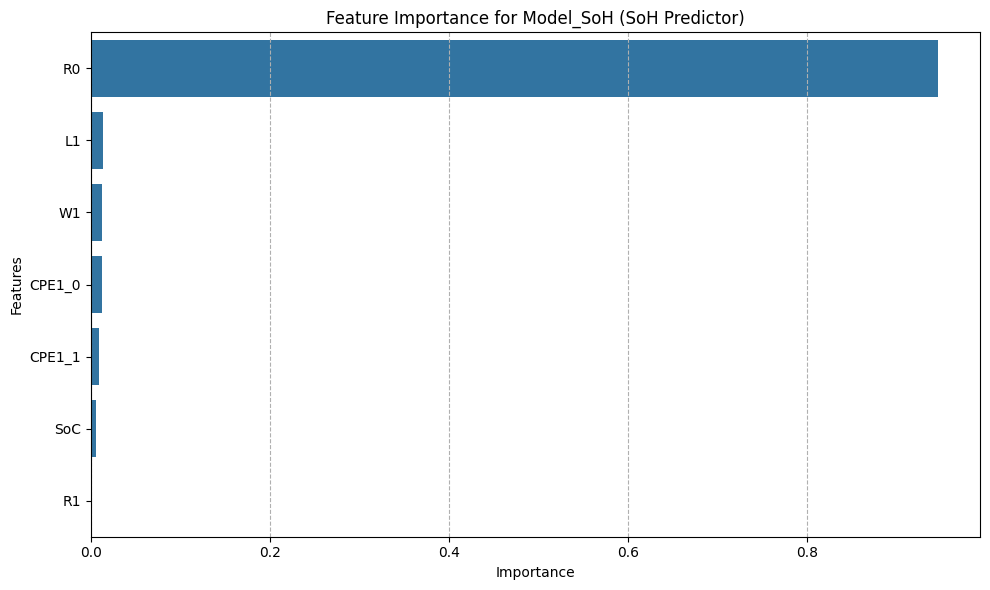


--- Evaluating End-to-End Chain on Test Set ---

End-to-End Test RMSE (with Tuned Model_Params): 2.57% SoH


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm
import matplotlib.pyplot as plt # <-- Added import
import seaborn as sns           # <-- Added import

# ===================================================================
# --- 1. Load All Data (Features & Targets) ---
# ===================================================================

# --- Load your pre-compiled datasets ---
# (Assuming 'all_battery_data_EIS', 'X_features_final', and 'best_model'
#  are loaded from your previous scripts)
#
# X_features_final = ... (Your (N, 109) feature DataFrame)
# all_battery_data_EIS = ... (Your main DataFrame)
# best_model = ... (Your tuned model from RandomizedSearchCV)
#
# --- For demonstration, we assume these are loaded ---


# --- Define all column groups ---
param_columns = ['L1', 'R0', 'R1', 'CPE1_0', 'CPE1_1', 'W1']
context_columns = ['SoC'] # User-provided
target_soh_column = 'SoH'

# --- Align all data ---
aligned_data = all_battery_data_EIS.loc[X_features_final.index]
X_spec = X_features_final
y_params = aligned_data[param_columns]
X_context = aligned_data[context_columns]
y_soh = aligned_data[target_soh_column]

# Convert all to NumPy arrays
X_spec_vals = X_spec.values
y_params_vals = y_params.values
X_context_vals = X_context.values
y_soh_vals = y_soh.values

# ===================================================================
# --- 2. Split Data (Train/Test) ---
# ===================================================================
# This split creates the *exact same* train/test sets used to tune your model
(X_spec_train, X_spec_test,
 X_context_train, X_context_test,
 y_params_train, y_params_test,
 y_soh_train, y_soh_test) = train_test_split(
    X_spec_vals, X_context_vals, y_params_vals, y_soh_vals, 
    test_size=0.2, random_state=42
)

# ===================================================================
# --- 3. Load the BEST Tuned Model_Params ---
# ===================================================================
Model_Params = best_model 
print(f"\nLoaded best tuned Model_Params (Type: {type(Model_Params)})")

# ===================================================================
# --- 4. Create Training Data for Model 2 ---
# ===================================================================
print("Generating training data for Model_SoH...")
predicted_params_for_training = Model_Params.predict(X_spec_train)
X_soh_train = np.concatenate([predicted_params_for_training, X_context_train], axis=1)
model_soh_features = param_columns + context_columns

# ===================================================================
# --- 5. Train Model 2 (Predicted Params + Context -> SoH) ---
# ===================================================================
Model_SoH = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Fitting Model_SoH (Predicted Params + Context -> SoH)...")
# We use .ravel() to make sure y_soh_train is a 1D array
Model_SoH.fit(X_soh_train, y_soh_train.ravel())

# ===================================================================
# --- 7. (Optional) Show Feature Importance for Model_SoH ---
# ===================================================================
print("\n--- Model_SoH Feature Importance ---")
importance = pd.Series(Model_SoH.feature_importances_, index=model_soh_features)
importance_sorted = importance.sort_values(ascending=False)
print(importance_sorted)

# --- NEW: GRAPHICAL FEATURE IMPORTANCE ---
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_sorted, y=importance_sorted.index, orient='h')
plt.title('Feature Importance for Model_SoH (SoH Predictor)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.grid(True, axis='x', linestyle='--')
plt.tight_layout()
plt.show()
# --- END OF NEW CODE ---


# ===================================================================
# --- 6. Evaluate the FULL CHAIN on Test Data ---
# ===================================================================
print("\n--- Evaluating End-to-End Chain on Test Set ---")

# 1. Run the first link (your *tuned* model)
predicted_params_test = Model_Params.predict(X_spec_test)

# 2. Create the test input for the second link
X_soh_test = np.concatenate([predicted_params_test, X_context_test], axis=1)

# 3. Run the second link
final_soh_pred = Model_SoH.predict(X_soh_test)

# 4. Calculate final, end-to-end RMSE
rmse = np.sqrt(mean_squared_error(y_soh_test, final_soh_pred))
print(f"\nEnd-to-End Test RMSE (with Tuned Model_Params): {rmse*100:.2f}% SoH")

# Model Evaluation


In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# --- 1. Define your data and column names ---
# (These should be loaded from your previous scripts)
# X_test, y_test (NumPy arrays from train_test_split)
# param_columns = ['L1', 'R0', 'R1', 'CPE1_0', 'CPE1_1', 'W1']
#
# rf_random, xgb_random, gpr_random (your fitted RandomizedSearchCV objects)

# --- 2. Get the best model from each search ---
best_model_rf = rf_random.best_estimator_
best_model_xgb = xgb_random.best_estimator_
best_model_gpr = gpr_random.best_estimator_

# --- 3. Get predictions from all three models ---
y_pred_rf = best_model_rf.predict(X_test)
y_pred_xgb = best_model_xgb.predict(X_test)
y_pred_gpr = best_model_gpr.predict(X_test)

# --- 4. Calculate RMSE for each parameter and store in a dictionary ---
results = {
    "RandomForest_RMSE": [],
    "XGBoost_RMSE": [],
    "GPR_RMSE": []
}

for i, name in enumerate(param_columns):
    rmse_rf = np.sqrt(mean_squared_error(y_test[:, i], y_pred_rf[:, i]))
    rmse_xgb = np.sqrt(mean_squared_error(y_test[:, i], y_pred_xgb[:, i]))
    rmse_gpr = np.sqrt(mean_squared_error(y_test[:, i], y_pred_gpr[:, i]))
    
    results["RandomForest_RMSE"].append(rmse_rf)
    results["XGBoost_RMSE"].append(rmse_xgb)
    results["GPR_RMSE"].append(rmse_gpr)

# --- 5. Create the comparison DataFrame ---
df_results = pd.DataFrame(results, index=param_columns)

# --- 6. Create and display the professional table ---
print("--- Model Performance Comparison (RMSE) ---")

# Format all numbers to 4-decimal scientific notation
styled_df = df_results.style.format("{:.4e}")

# Add a caption
styled_df = styled_df.set_caption(
    "<b>Table 1: Model Performance Comparison (RMSE)</b><br>Lower values are better."
)

# Highlight the minimum (best) RMSE in each row (axis=1)
styled_df = styled_df.highlight_min(
    axis=1, 
    props='font-weight:bold; background-color:#d4edda;' # Green background for best
)

# Add gridlines and professional styling
styled_df = styled_df.set_table_styles([
    {'selector': 'th.col_heading', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), ('font-weight', 'bold')]},
    {'selector': 'th.row_heading', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid #ddd')]},
    {'selector': 'caption', 'props': [('color', 'black'), ('font-size', '1.2em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
])

# IMPORTANT: To display the styled table in a Jupyter Notebook,
# this 'styled_df' object must be the *last line* in the cell.
styled_df

--- Model Performance Comparison (RMSE) ---


,RandomForest_RMSE,XGBoost_RMSE,GPR_RMSE
L1,2.2159e-08,2.2850e-08,1.9612e-08
R0,1.1115e-02,1.0847e-02,1.0458e-02
R1,1.3505e-01,1.3385e-01,9.5563e-02
CPE1_0,8.3092e-01,8.6897e-01,8.0661e-01
CPE1_1,7.3468e-02,9.0730e-02,7.2553e-02
W1,1.2651e-03,7.6889e-04,6.7058e-04


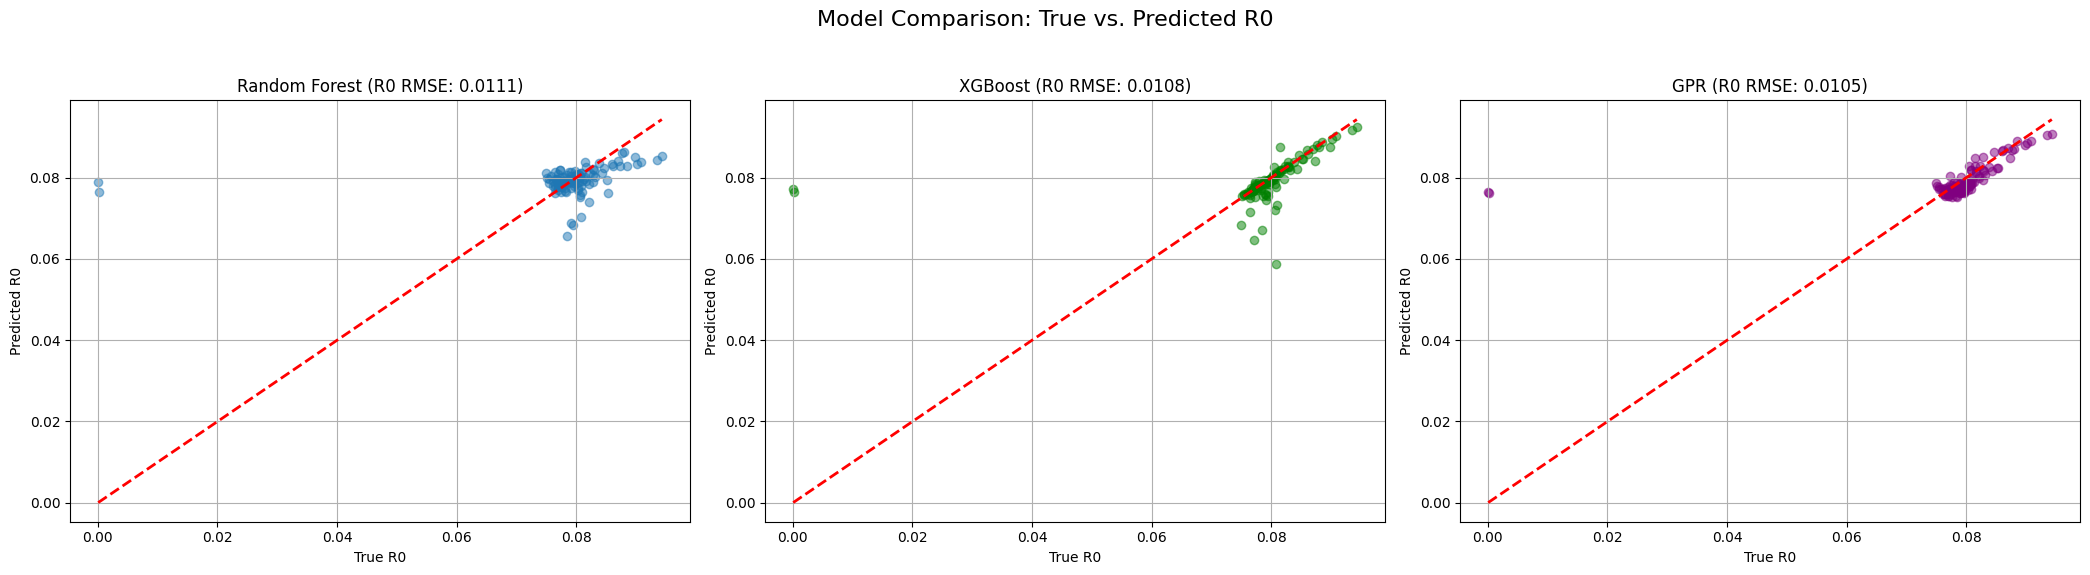

In [8]:
import matplotlib.pyplot as plt

# --- 1. Get the index for your main parameter (e.g., R1) ---
r0_index = param_columns.index('R0')

# --- 2. Get the true values and predicted values for R1 ---
y_true_r0 = y_test[:, r0_index]
y_pred_r0_rf = y_pred_rf[:, r0_index]
y_pred_r0_xgb = y_pred_xgb[:, r0_index]
y_pred_r0_gpr = y_pred_gpr[:, r0_index]

# --- 3. Get the R1-specific RMSEs from your results table ---
rmse_r0_rf = df_results.loc['R0']['RandomForest_RMSE']
rmse_r0_xgb = df_results.loc['R0']['XGBoost_RMSE']
rmse_r0_gpr = df_results.loc['R0']['GPR_RMSE']

# --- 4. Create the 1x3 Subplot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Model Comparison: True vs. Predicted R0', fontsize=16)

# Find the min/max for a consistent 'perfection line'
min_val = min(y_true_r0.min(), y_pred_r0_rf.min(), y_pred_r0_xgb.min(), y_pred_r0_gpr.min())
max_val = max(y_true_r0.max(), y_pred_r0_rf.max(), y_pred_r0_xgb.max(), y_pred_r0_gpr.max())

# Plot 1: Random Forest
ax1.scatter(y_true_r0, y_pred_r0_rf, alpha=0.5)
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax1.set_title(f'Random Forest (R0 RMSE: {rmse_r0_rf:.4f})')
ax1.set_xlabel('True R0')
ax1.set_ylabel('Predicted R0')
ax1.grid(True)

# Plot 2: XGBoost
ax2.scatter(y_true_r0, y_pred_r0_xgb, alpha=0.5, color='green')
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax2.set_title(f'XGBoost (R0 RMSE: {rmse_r0_xgb:.4f})')
ax2.set_xlabel('True R0')
ax2.set_ylabel('Predicted R0')
ax2.grid(True)

# Plot 3: GPR
ax3.scatter(y_true_r0, y_pred_r0_gpr, alpha=0.5, color='purple')
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax3.set_title(f'GPR (R0 RMSE: {rmse_r0_gpr:.4f})')
ax3.set_xlabel('True R0')
ax3.set_ylabel('Predicted R0')
ax3.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

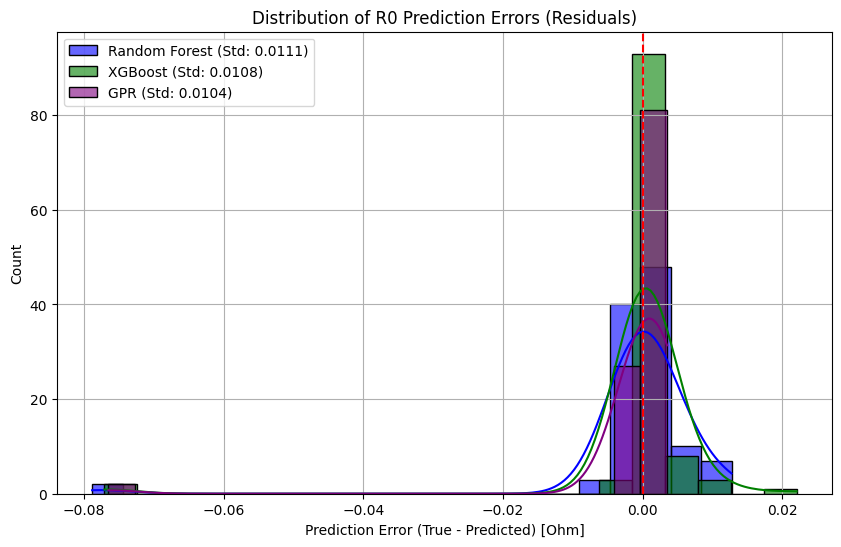

In [9]:
import seaborn as sns

# --- 1. Calculate the errors (residuals) for R1 ---
errors_rf = y_true_r0 - y_pred_r0_rf
errors_xgb = y_true_r0 - y_pred_r0_xgb
errors_gpr = y_true_r0 - y_pred_r0_gpr

# --- 2. Plot all three distributions on one graph ---
plt.figure(figsize=(10, 6))
sns.histplot(errors_rf, kde=True, label=f'Random Forest (Std: {errors_rf.std():.4f})', color='blue', alpha=0.6)
sns.histplot(errors_xgb, kde=True, label=f'XGBoost (Std: {errors_xgb.std():.4f})', color='green', alpha=0.6)
sns.histplot(errors_gpr, kde=True, label=f'GPR (Std: {errors_gpr.std():.4f})', color='purple', alpha=0.6)

plt.title('Distribution of R0 Prediction Errors (Residuals)')
plt.xlabel('Prediction Error (True - Predicted) [Ohm]')
plt.ylabel('Count')
plt.axvline(0, color='red', linestyle='--') # The 'perfect prediction' line
plt.legend()
plt.grid(True)
plt.show()

# Code for Deep Learning Pipeline

In [10]:
breakpoint()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.interpolate import interp1d

# --- PyTorch Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# --- (Assuming 'all_battery_data_EIS' and 'col_names' exist) ---
# Make sure your 'circuit_model' (e.g., L1-R0-p(R1,CPE1)-W1)
# parameters are correctly listed here.
param_columns = ['L1', 'R0', 'R1', 'CPE1_0', 'CPE1_1', 'W1']
col_names = ['Frequency(Hz)', 'R(ohm)', 'X(ohm)']
# ===================================================================
# PHASE 0: DATA & FEATURE ENGINEERING (Prerequisite)
# ===================================================================

print("--- Phase 0: Preparing Data & Engineering Features ---")

# 1. Clean and align all data
df_cleaned = all_battery_data_EIS.dropna(
    subset=param_columns + ['SoH']
).reset_index(drop=True)

# 2. Define fixed frequencies for features
fixed_freqs = np.logspace(-2, 4, 50) # 50 points from 0.01 Hz to 10 kHz

# 3. Loop through files and engineer X features
eis_features_list = []
for index, row in tqdm(df_cleaned.iterrows(), total=len(df_cleaned), desc="Processing Spectra"):
    f = row['EIS_File']
    try:
        raw_df = pd.read_csv(f, sep='\t', names=col_names)
        raw_df = raw_df.sort_values(by='Frequency(Hz)')
        
        f_x = raw_df['Frequency(Hz)'].values
        R = raw_df['R(ohm)'].values
        X = raw_df['X(ohm)'].values
        
        # Create interpolation functions
        interp_R = interp1d(f_x, R, bounds_error=False, fill_value='extrapolate')
        interp_X = interp1d(f_x, X, bounds_error=False, fill_value='extrapolate')
        
        # Get features at our fixed frequencies
        R_features = interp_R(fixed_freqs)
        X_features = interp_X(fixed_freqs)
        
        # Combine R and X to make one long feature vector
        features = np.concatenate([R_features, X_features])
        eis_features_list.append(features)
        
    except Exception as e:
        tqdm.write(f"Warning: Could not process file {f}. Error: {e}")
        eis_features_list.append(None) # Add a placeholder

# 4. Create the final aligned X and y DataFrames
r_cols = [f'R_{freq:.2f}Hz' for freq in fixed_freqs]
x_cols = [f'X_{freq:.2f}Hz' for freq in fixed_freqs]

X_features_df = pd.DataFrame(eis_features_list, columns=r_cols + x_cols)
y_params_df = df_cleaned[param_columns]
y_soh_df = df_cleaned[['SoH']] # Use [['SoH']] to keep it as a DataFrame

# 5. Drop any rows that failed feature engineering
failed_indices = X_features_df[X_features_df.isnull().any(axis=1)].index
X_features_final = X_features_df.drop(failed_indices)
y_params_final = y_params_df.drop(failed_indices)
y_soh_final = y_soh_df.drop(failed_indices)

print(f"Data ready: X_features ({X_features_final.shape}), y_params ({y_params_final.shape}), y_soh ({y_soh_final.shape})")

# ===================================================================
# PHASE 1: PYTORCH SETUP (Dataset & Model Architecture)
# ===================================================================

print("\n--- Phase 1: Setting up PyTorch components ---")

# 1. Scale features
# Scaling is CRITICAL for neural networks
scaler_X = StandardScaler()
scaler_y_params = StandardScaler()

X_scaled = scaler_X.fit_transform(X_features_final)
y_params_scaled = scaler_y_params.fit_transform(y_params_final)
y_soh_values = y_soh_final.values # No scaling needed for SoH (already 0-1)

# 2. Train/Test Split
(X_train, X_val, 
 y_params_train, y_params_val, 
 y_soh_train, y_soh_val) = train_test_split(
    X_scaled, y_params_scaled, y_soh_values, test_size=0.2, random_state=42
)

# 3. Custom PyTorch Dataset
class EISDataset(Dataset):
    def __init__(self, features, params, soh):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y_params = torch.tensor(params, dtype=torch.float32)
        self.y_soh = torch.tensor(soh, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_params[idx], self.y_soh[idx]

train_dataset = EISDataset(X_train, y_params_train, y_soh_train)
val_dataset = EISDataset(X_val, y_params_val, y_soh_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 4. Define the Multi-Head Model
class MultiHeadEISModel(nn.Module):
    def __init__(self, input_size, num_params):
        super(MultiHeadEISModel, self).__init__()
        
        # Shared Body
        self.shared_body = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Head 1: Parameter Prediction
        self.param_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_params) # No activation (linear output for regression)
        )
        
        # Head 2: SoH Prediction
        self.soh_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1), # No activation (linear output for regression)
            nn.Sigmoid() # Add Sigmoid to bound output between 0 and 1
        )

    def forward(self, x):
        # Pass input through the shared body
        shared_output = self.shared_body(x)
        
        # Pass shared output to each head
        params_pred = self.param_head(shared_output)
        soh_pred = self.soh_head(shared_output)
        
        return params_pred, soh_pred

# ===================================================================
# PHASE 2: MODEL TRAINING
# ===================================================================

print("\n--- Phase 2: Starting Model Training ---")

# 1. Setup Model, Loss, Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

INPUT_SIZE = X_features_final.shape[1]
NUM_PARAMS = y_params_final.shape[1]
NUM_EPOCHS = 50 # Increase this for better results
LEARNING_RATE = 0.001

model = MultiHeadEISModel(INPUT_SIZE, NUM_PARAMS).to(device)
loss_params_fn = nn.MSELoss()
loss_soh_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 2. Define your loss weights
alpha = 0.7 # Weight for SoH loss (as per your example)
beta = 0.3  # Weight for Parameter loss

# 3. Training Loop
for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0
    
    for features, true_params, true_soh in train_loader:
        features = features.to(device)
        true_params = true_params.to(device)
        true_soh = true_soh.to(device)
        
        # --- Forward Pass ---
        pred_params, pred_soh = model(features)
        
        # --- Calculate Combined Loss ---
        loss_params = loss_params_fn(pred_params, true_params)
        loss_soh = loss_soh_fn(pred_soh, true_soh) # .view(-1, 1) not needed, shape is correct
        
        loss_total = (alpha * loss_soh) + (beta * loss_params)
        
        # --- Backward Pass ---
        optimizer.zero_grad()
        loss_total.backward()
        optimizer.step()
        
        total_train_loss += loss_total.item()

    # --- Validation ---
    model.eval()
    total_val_loss = 0
    total_val_soh_loss = 0
    total_val_params_loss = 0
    
    with torch.no_grad():
        for features, true_params, true_soh in val_loader:
            features = features.to(device)
            true_params = true_params.to(device)
            true_soh = true_soh.to(device)
            
            pred_params, pred_soh = model(features)
            
            loss_params = loss_params_fn(pred_params, true_params)
            loss_soh = loss_soh_fn(pred_soh, true_soh)
            loss_total = (alpha * loss_soh) + (beta * loss_params)
            
            total_val_loss += loss_total.item()
            total_val_soh_loss += loss_soh.item()
            total_val_params_loss += loss_params.item()
            
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    avg_soh_loss = total_val_soh_loss / len(val_loader)
    avg_params_loss = total_val_params_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] - Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} (SoH: {avg_soh_loss:.6f}, Params: {avg_params_loss:.6f})")

print("\n--- Training Complete ---")

# --- 4. Final Evaluation on Test Set ---
model.eval()
with torch.no_grad():
    # Predict on the entire validation set
    all_features = torch.tensor(X_val, dtype=torch.float32).to(device)
    true_params = torch.tensor(y_params_val, dtype=torch.float32).to(device)
    true_soh = torch.tensor(y_soh_val, dtype=torch.float32).to(device)
    
    pred_params_scaled, pred_soh = model(all_features)
    
    # --- De-scale the predictions to be human-readable ---
    pred_params = scaler_y_params.inverse_transform(pred_params_scaled.cpu().numpy())
    
    # --- Calculate Final Errors ---
    soh_rmse = np.sqrt(mean_squared_error(true_soh.cpu().numpy(), pred_soh.cpu().numpy()))
    
    print(f"\n--- Final Model Evaluation ---")
    print(f"SoH Prediction RMSE: {soh_rmse*100:.2f}% SoH")
    
    # Calculate RMSE for each parameter
    for i, name in enumerate(param_columns):
        # Compare the i-th column of y_params_val with the i-th column of pred_params
        param_rmse = np.sqrt(mean_squared_error(y_params_val[:, i], pred_params[:, i]))
        print(f"  - {name} RMSE: {param_rmse:.4f}")

--- Phase 0: Preparing Data & Engineering Features ---


Processing Spectra: 100%|██████████| 549/549 [00:00<00:00, 1220.68it/s]


Data ready: X_features ((549, 100)), y_params ((549, 6)), y_soh ((549, 1))

--- Phase 1: Setting up PyTorch components ---

--- Phase 2: Starting Model Training ---
Using device: cpu
